# Dynamic probabilistic models in Pyro: state-space inference and SIR dynamics

**ProbAI 2026 — Day 1 afternoon companion notebook 2**

This notebook moves beyond independent observations. We study two models in which the
present depends on the past:

1. a **linear Gaussian state-space model**, where a continuous latent state evolves through time;
2. an **SIR epidemic model**, where nonlinear compartment dynamics generate noisy case counts.

The recurring workflow is

$$
\text{simulate} \rightarrow \text{specify dynamics} \rightarrow
\text{infer} \rightarrow \text{predict} \rightarrow \text{criticize}.
$$

Every code cell is complete. Set the variable `FAST_RUN=1` before
execution to use a short smoke-test configuration.


## Learning goals

By the end, you should be able to:

1. express Markov dynamics with time-indexed Pyro sample sites;
2. embed deterministic nonlinear dynamics inside a probabilistic model;
3. infer constrained SIR parameters from noisy count observations;


In [1]:
# Colab/local setup. Existing packages are left untouched.
import importlib
import subprocess
import sys


def ensure_package(import_name, pip_name=None, extra_args=None):
    try:
        importlib.import_module(import_name)
        print(f"✓ {import_name} already available")
    except ImportError:
        package = pip_name or import_name
        command = [sys.executable, "-m", "pip", "install", "-q"]
        command.extend(extra_args or [])
        command.append(package)
        print(f"Installing {package} ...")
        subprocess.check_call(command)


# The CPU index avoids downloading CUDA libraries in a fresh local environment.
ensure_package(
    "torch",
    "torch",
    extra_args=["--index-url", "https://download.pytorch.org/whl/cpu"],
)
ensure_package("pyro", "pyro-ppl")
ensure_package("matplotlib")
ensure_package("pandas")


✓ torch already available
Installing pyro-ppl ...
✓ matplotlib already available
✓ pandas already available


In [2]:
import math
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
import torch

from pyro.infer import Predictive, SVI, Trace_ELBO
from pyro.infer.autoguide import AutoLowRankMultivariateNormal, AutoMultivariateNormal, AutoNormal

torch.set_default_dtype(torch.float32)
pyro.enable_validation(True)
pyro.set_rng_seed(19)
np.random.seed(19)
random.seed(19)

FAST_RUN = True
LGSSM_STEPS = 180 if FAST_RUN else 1200
SIR_STEPS = 220 if FAST_RUN else 1600
NUM_DRAWS = 120 if FAST_RUN else 800

print("Pyro:", pyro.__version__)
print("PyTorch:", torch.__version__)
print("Fast run:", FAST_RUN)


Pyro: 1.9.1
PyTorch: 2.11.0+cpu
Fast run: True


## 1. A linear Gaussian state-space model

Let the unobserved state be $x_t$ and the measurement be $y_t$:

$$
x_0 \sim \mathrm N(0,1),\qquad \\
x_t \mid x_{t-1} \sim \mathrm N(\phi x_{t-1}, q),\qquad \\
y_t \mid x_t \sim \mathrm N(x_t,r).
$$

The three main inferential tasks are:

- **filtering:** infer $x_t$ using $y_{0:t}$;
- **smoothing:** infer earlier states using the complete observed sequence;
- **forecasting:** propagate uncertainty beyond the observed interval.

We will perform smoothing with SVI and then simulate forecasts from posterior draws.


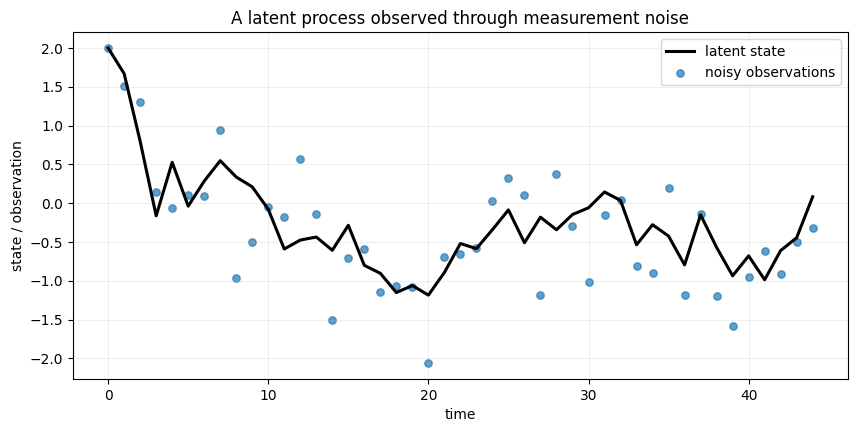

In [3]:
def simulate_lgssm(
    T=45,
    phi=0.88,
    process_scale=0.32,
    obs_scale=0.55,
    initial_state=2.0,
    seed=19,
):
    generator = torch.Generator().manual_seed(seed)
    states = [torch.tensor(initial_state)]
    observations = [states[0] + obs_scale * torch.randn((), generator=generator)]

    for _ in range(1, T):
        state = phi * states[-1] + process_scale * torch.randn((), generator=generator)
        observation = state + obs_scale * torch.randn((), generator=generator)
        states.append(state)
        observations.append(observation)

    return torch.stack(states), torch.stack(observations)


TRUE_LGSSM = {"phi": 0.88, "process_scale": 0.32, "obs_scale": 0.55}
latent_true, y_state = simulate_lgssm(**TRUE_LGSSM)
T_OBS = len(y_state)

plt.figure(figsize=(10, 4.5))
plt.plot(latent_true, color="black", linewidth=2.2, label="latent state")
plt.scatter(range(T_OBS), y_state, s=28, alpha=0.7, label="noisy observations")
plt.xlabel("time")
plt.ylabel("state / observation")
plt.title("A latent process observed through measurement noise")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### The Pyro program

Each latent state receives a unique name such as `x_12`. The loop is ordinary Python;
`pyro.markov` adds information that successive iterations have local temporal dependence.

The model accepts an observed prefix and can continue beyond it. This makes the same
program useful for fitting and forecasting.


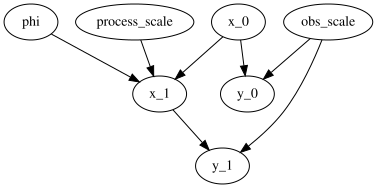

In [5]:
def lgssm_model(y=None, T=2):
    if T is None:
        if y is None:
            raise ValueError("Provide y or T.")
        T = len(y)

    phi = pyro.sample("phi", dist.Uniform(0.50, 0.99))
    process_scale = pyro.sample("process_scale", dist.LogNormal(-1.2, 0.45))
    obs_scale = pyro.sample("obs_scale", dist.LogNormal(-0.7, 0.40))

    x_prev = pyro.sample("x_0", dist.Normal(0.0, 2.0))
    states = [x_prev]
    y_t = y[0] if y is not None and len(y) > 0 else None
    pyro.sample("y_0", dist.Normal(x_prev, obs_scale), obs=y_t)

    for t in pyro.markov(range(1, T)):
        x_t = pyro.sample(
            f"x_{t}",
            dist.Normal(phi * x_prev, process_scale),
        )
        y_t = y[t] if y is not None and t < len(y) else None
        pyro.sample(f"y_{t}", dist.Normal(x_t, obs_scale), obs=y_t)
        states.append(x_t)
        x_prev = x_t

    return torch.stack(states)
pyro.render_model(model=lgssm_model, model_args=())

### Guide geometry matters especially for time series

After observing $y_t$, neighboring states remain strongly dependent. A perturbation in
$x_t$ can be compensated by nearby states and by the process-noise scale.

We compare:

- `AutoNormal`: independent Gaussian factors in unconstrained space;
- `AutoLowRankMultivariateNormal`: a diagonal covariance plus learned low-rank correlations.

This is not a contest with a universal winner. It is a demonstration that the guide is a
modeling choice about posterior geometry.


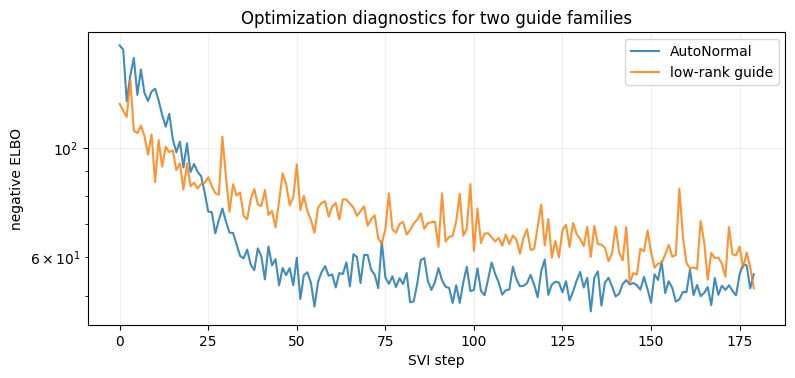

In [11]:
def fit_svi(model, guide, args, num_steps, lr=0.025):
    pyro.clear_param_store()
    svi = SVI(
        model,
        guide,
        pyro.optim.ClippedAdam({"lr": lr, "clip_norm": 10.0}),
        loss=Trace_ELBO(),
    )
    losses = []
    for step in range(num_steps):
        losses.append(svi.step(*args))
    return losses


def posterior_draws(model, guide, args, return_sites, num_samples=NUM_DRAWS):
    predictive = Predictive(
        model,
        guide=guide,
        num_samples=num_samples,
        return_sites=return_sites,
    )
    with torch.no_grad():
        return {name: value.detach().clone() for name, value in predictive(*args).items()}


mean_field_guide = AutoNormal(lgssm_model)
mean_field_losses = fit_svi(
    lgssm_model,
    mean_field_guide,
    (y_state, T_OBS),
    num_steps=LGSSM_STEPS,
)
mean_field_draws = posterior_draws(
    lgssm_model,
    mean_field_guide,
    (y_state, T_OBS),
    return_sites=("phi", "process_scale", "obs_scale", "_RETURN"),
)

low_rank_guide = AutoLowRankMultivariateNormal(lgssm_model, rank=8)
low_rank_losses = fit_svi(
    lgssm_model,
    low_rank_guide,
    (y_state, T_OBS),
    num_steps=LGSSM_STEPS,
)
low_rank_draws = posterior_draws(
    lgssm_model,
    low_rank_guide,
    (y_state, T_OBS),
    return_sites=("phi", "process_scale", "obs_scale", "_RETURN"),
)

plt.figure(figsize=(9, 3.8))
plt.plot(mean_field_losses, alpha=0.85, label="AutoNormal")
plt.plot(low_rank_losses, alpha=0.85, label="low-rank guide")
plt.yscale("log")
plt.xlabel("SVI step")
plt.ylabel("negative ELBO")
plt.title("Optimization diagnostics for two guide families")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


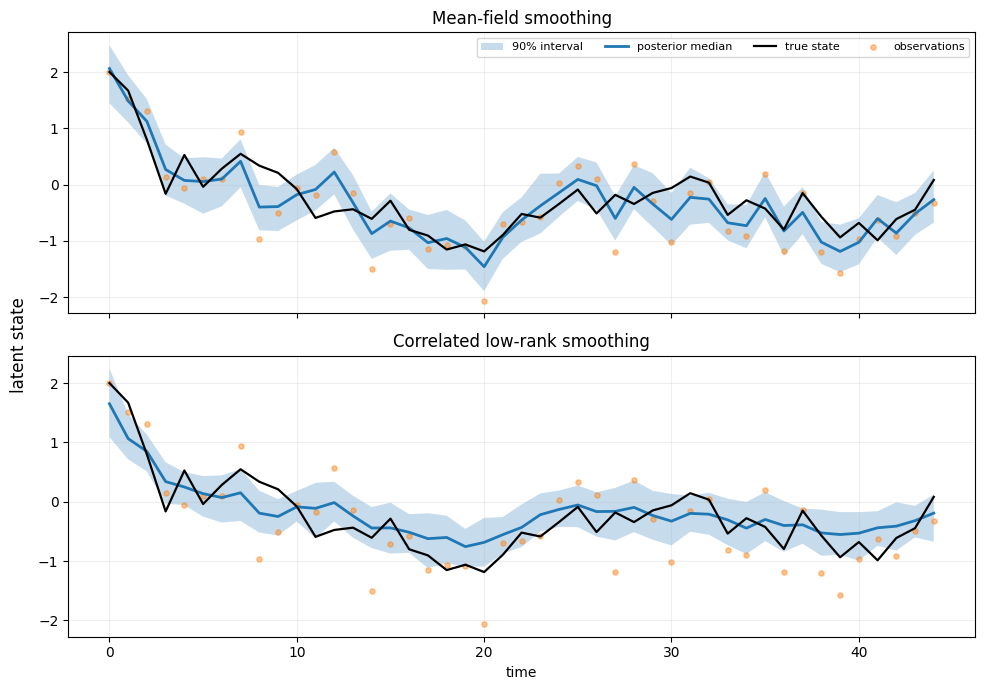

In [12]:
def interval(draws, probability=0.90):
    tail = (1.0 - probability) / 2.0
    return (
        torch.quantile(draws, tail, dim=0),
        torch.quantile(draws, 0.5, dim=0),
        torch.quantile(draws, 1.0 - tail, dim=0),
    )


def plot_smoothed_states(draws_by_guide):
    fig, axes = plt.subplots(len(draws_by_guide), 1, figsize=(10, 7), sharex=True)
    time = torch.arange(T_OBS)

    for axis, (name, draws) in zip(axes, draws_by_guide.items()):
        lower, median, upper = interval(draws["_RETURN"])
        axis.fill_between(time, lower, upper, alpha=0.25, label="90% interval")
        axis.plot(time, median, linewidth=2.0, label="posterior median")
        axis.plot(time, latent_true, color="black", linewidth=1.6, label="true state")
        axis.scatter(time, y_state, s=14, alpha=0.45, label="observations")
        axis.set_title(name)
        axis.grid(alpha=0.2)

    axes[-1].set_xlabel("time")
    axes[0].legend(ncol=4, fontsize=8)
    fig.supylabel("latent state")
    fig.tight_layout()
    plt.show()


plot_smoothed_states(
    {
        "Mean-field smoothing": mean_field_draws,
        "Correlated low-rank smoothing": low_rank_draws,
    }
)


In [13]:
def parameter_summary(draws, truth):
    rows = []
    for name, true_value in truth.items():
        lower, median, upper = interval(draws[name])
        rows.append(
            {
                "parameter": name,
                "true": true_value,
                "median": median.item(),
                "5%": lower.item(),
                "95%": upper.item(),
            }
        )
    return pd.DataFrame(rows).set_index("parameter")


parameter_summary(low_rank_draws, TRUE_LGSSM).round(3)


,true,median,5%,95%
parameter,,,,
phi,0.88,0.685,0.560,0.823
process_scale,0.32,0.284,0.248,0.312
obs_scale,0.55,0.530,0.451,0.636


### Forecast by propagating posterior uncertainty

We first draw the final smoothed state and dynamic parameters from the fitted posterior.
We then simulate the transition and observation equations forward. Uncertainty grows because
each future step introduces new process and measurement noise.


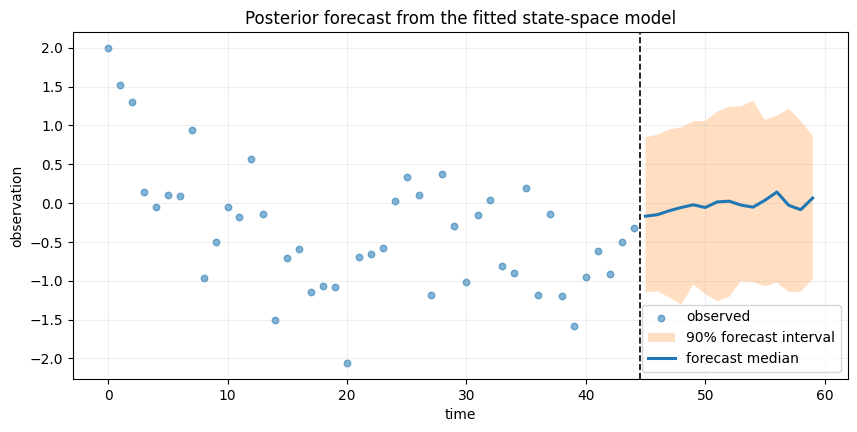

In [14]:
def forecast_lgssm(draws, horizon=15):
    phi = draws["phi"]
    process_scale = draws["process_scale"]
    obs_scale = draws["obs_scale"]
    state = draws["_RETURN"][:, -1]

    future_states = []
    future_observations = []
    for _ in range(horizon):
        state = dist.Normal(phi * state, process_scale).sample()
        observation = dist.Normal(state, obs_scale).sample()
        future_states.append(state)
        future_observations.append(observation)

    return torch.stack(future_states, dim=-1), torch.stack(future_observations, dim=-1)


HORIZON = 15
future_state, future_y = forecast_lgssm(low_rank_draws, HORIZON)
f_lower, f_median, f_upper = interval(future_y)
forecast_time = torch.arange(T_OBS, T_OBS + HORIZON)

plt.figure(figsize=(10, 4.5))
plt.scatter(range(T_OBS), y_state, s=22, alpha=0.55, label="observed")
plt.fill_between(forecast_time, f_lower, f_upper, alpha=0.25, label="90% forecast interval")
plt.plot(forecast_time, f_median, linewidth=2.2, label="forecast median")
plt.axvline(T_OBS - 0.5, color="black", linestyle="--", linewidth=1.2)
plt.xlabel("time")
plt.ylabel("observation")
plt.title("Posterior forecast from the fitted state-space model")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### State-space discussion

- For large linear Gaussian systems, specialized distributions such as `GaussianHMM` can exploit
  temporal structure more efficiently than an explicit Python loop.


## 2. SIR dynamics with probabilistic observations

The SIR model divides a population into susceptible, infectious, and recovered compartments:

$$
\begin{aligned}
\Delta I_t^{\text{new}} &= \beta S_t I_t/N,\\
\Delta R_t &= \gamma I_t,\\
S_{t+1} &= S_t-\Delta I_t^{\text{new}},\\
I_{t+1} &= I_t+\Delta I_t^{\text{new}}-\Delta R_t,\\
R_{t+1} &= R_t+\Delta R_t.
\end{aligned}
$$

Here the compartment dynamics are deterministic conditional on the parameters. The observations
are stochastic:

$$
C_t \sim \operatorname{Poisson}(\rho\,\Delta I_t^{\text{new}}).
$$

This separation is useful: domain equations specify the latent mechanism, while a probability
distribution specifies how the mechanism becomes data.


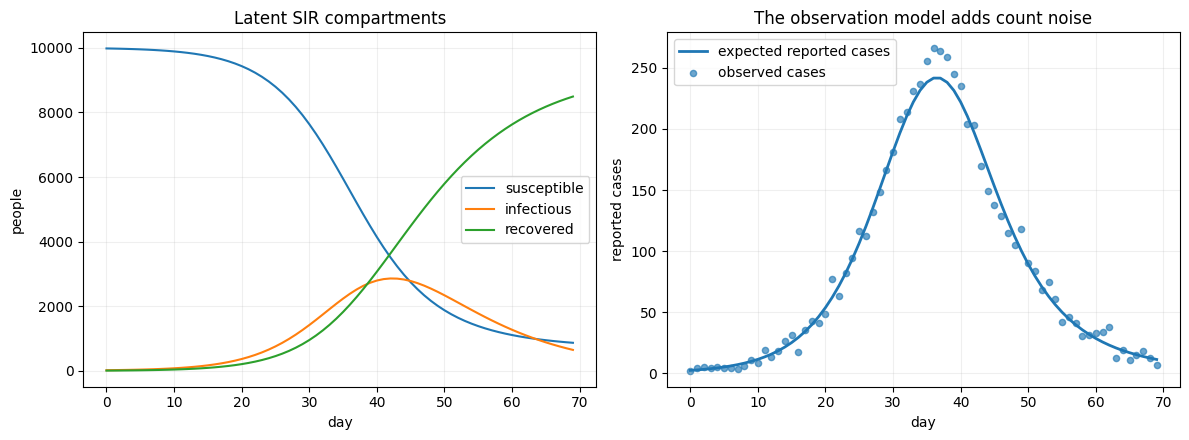

In [15]:
def sir_dynamics(beta, gamma, population, initial_infectious, T):
    susceptible = population - initial_infectious
    infectious = initial_infectious
    recovered = torch.zeros_like(infectious)

    susceptible_path = []
    infectious_path = []
    recovered_path = []
    incidence_path = []

    for _ in range(T):
        new_infections = beta * susceptible * infectious / population
        new_recoveries = gamma * infectious

        susceptible = susceptible - new_infections
        infectious = infectious + new_infections - new_recoveries
        recovered = recovered + new_recoveries

        susceptible_path.append(susceptible)
        infectious_path.append(infectious)
        recovered_path.append(recovered)
        incidence_path.append(new_infections)

    return torch.stack(
        [
            torch.stack(susceptible_path),
            torch.stack(infectious_path),
            torch.stack(recovered_path),
            torch.stack(incidence_path),
        ],
        dim=-1,
    )


POPULATION = 10_000.0
T_SIR = 70
TRUE_SIR = {"beta": 0.28, "gamma": 0.10, "rho": 0.65, "initial_infectious": 12.0}

true_sir_path = sir_dynamics(
    torch.tensor(TRUE_SIR["beta"]),
    torch.tensor(TRUE_SIR["gamma"]),
    torch.tensor(POPULATION),
    torch.tensor(TRUE_SIR["initial_infectious"]),
    T_SIR,
)
true_expected_cases = TRUE_SIR["rho"] * true_sir_path[:, 3]
observed_cases = dist.Poisson(true_expected_cases.clamp_min(1e-4)).sample()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(true_sir_path[:, 0], label="susceptible")
axes[0].plot(true_sir_path[:, 1], label="infectious")
axes[0].plot(true_sir_path[:, 2], label="recovered")
axes[0].set_title("Latent SIR compartments")
axes[0].set_xlabel("day")
axes[0].set_ylabel("people")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(true_expected_cases, linewidth=2.0, label="expected reported cases")
axes[1].scatter(range(T_SIR), observed_cases, s=20, alpha=0.65, label="observed cases")
axes[1].set_title("The observation model adds count noise")
axes[1].set_xlabel("day")
axes[1].set_ylabel("reported cases")
axes[1].legend()
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()


### The SIR Pyro model

The model has only four stochastic parameters, but they are strongly coupled. For example,
the growth rate is informed largely by the ratio $R_0=\beta/\gamma$, while the reporting
probability trades off against the number of infections.

Beta priors keep daily rates in $(0,1)$. A log-normal prior keeps the initial number of
infectious people positive.


In [16]:
def sir_model(cases=None, population=POPULATION, T=None):
    if T is None:
        if cases is None:
            raise ValueError("Provide cases or T.")
        T = len(cases)

    beta = pyro.sample("beta", dist.Beta(2.0, 5.0))
    gamma = pyro.sample("gamma", dist.Beta(2.0, 18.0))
    rho = pyro.sample("rho", dist.Beta(8.0, 4.0))
    initial_infectious = pyro.sample(
        "initial_infectious",
        dist.LogNormal(math.log(10.0), 0.45),
    )

    path = sir_dynamics(
        beta,
        gamma,
        torch.as_tensor(population),
        initial_infectious,
        T,
    )
    expected_cases = (rho * path[:, 3]).clamp_min(1e-4)

    with pyro.plate("time", T):
        pyro.sample("cases", dist.Poisson(expected_cases), obs=cases)

    # Columns: susceptible, infectious, recovered, incidence, expected cases.
    return torch.cat([path, expected_cases.unsqueeze(-1)], dim=-1)


          Trace Shapes:     
           Param Sites:     
          Sample Sites:     
              beta dist    |
                  value    |
               log_prob    |
             gamma dist    |
                  value    |
               log_prob    |
               rho dist    |
                  value    |
               log_prob    |
initial_infectious dist    |
                  value    |
               log_prob    |
              time dist    |
                  value 70 |
               log_prob    |
             cases dist 70 |
                  value 70 |
               log_prob 70 |


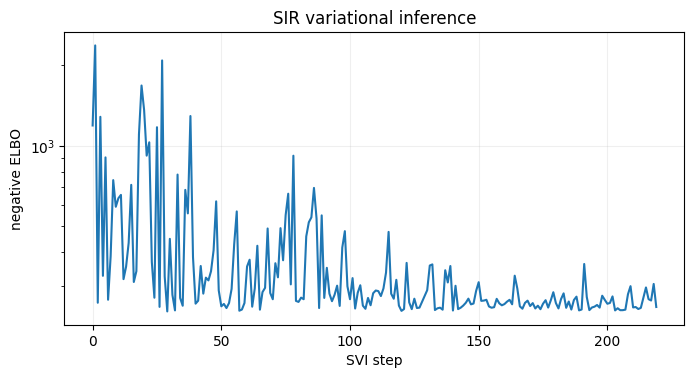

In [17]:
sir_trace = poutine.trace(sir_model).get_trace(observed_cases, POPULATION, T_SIR)
sir_trace.compute_log_prob()
print(sir_trace.format_shapes())

# A full-rank guide is affordable here because the latent space contains
# only four global parameters.
sir_guide = AutoMultivariateNormal(sir_model)
sir_losses = fit_svi(
    sir_model,
    sir_guide,
    (observed_cases, POPULATION, T_SIR),
    num_steps=SIR_STEPS,
    lr=0.018,
)

plt.figure(figsize=(8, 3.8))
plt.plot(sir_losses)
plt.yscale("log")
plt.xlabel("SVI step")
plt.ylabel("negative ELBO")
plt.title("SIR variational inference")
plt.grid(alpha=0.2)
plt.show()


In [18]:
sir_draws = posterior_draws(
    sir_model,
    sir_guide,
    (observed_cases, POPULATION, T_SIR),
    return_sites=("beta", "gamma", "rho", "initial_infectious", "_RETURN"),
)

sir_rows = []
for name, true_value in TRUE_SIR.items():
    lower, median, upper = interval(sir_draws[name])
    sir_rows.append(
        {
            "parameter": name,
            "true": true_value,
            "median": median.item(),
            "5%": lower.item(),
            "95%": upper.item(),
        }
    )

r0_draws = sir_draws["beta"] / sir_draws["gamma"]
r0_lower, r0_median, r0_upper = interval(r0_draws)
sir_rows.append(
    {
        "parameter": "R0 = beta / gamma",
        "true": TRUE_SIR["beta"] / TRUE_SIR["gamma"],
        "median": r0_median.item(),
        "5%": r0_lower.item(),
        "95%": r0_upper.item(),
    }
)

pd.DataFrame(sir_rows).set_index("parameter").round(3)


,true,median,5%,95%
parameter,,,,
beta,0.28,0.266,0.254,0.279
gamma,0.10,0.084,0.074,0.096
rho,0.65,0.647,0.634,0.669
initial_infectious,12.00,11.957,9.594,15.359
R0 = beta / gamma,2.80,3.180,2.855,3.528


### Posterior predictive checking

We now generate replicated case-count sequences. The median trajectory checks whether the
fitted dynamics capture the overall epidemic shape. The predictive interval also checks the
Poisson variance assumption.

A fit can recover the main curve and still fail systematically—for example, if reported cases
show weekday effects, delayed reporting, changing contact rates, or more variability than a
Poisson distribution permits.


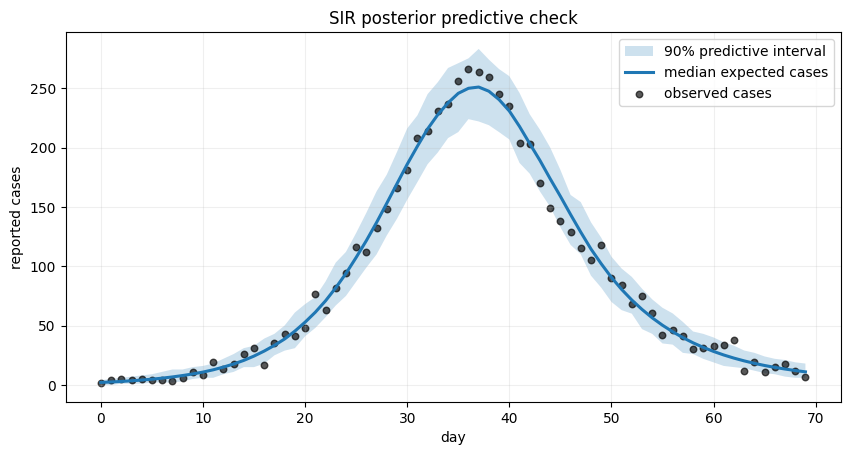

,observed,replicated median,replicated 90% interval
discrepancy,,,
peak size,266.0,266.0,"(242.9499969482422, 289.0999755859375)"
peak day,36.0,37.0,"(34.0, 39.04999542236328)"


In [19]:
sir_predictive = Predictive(
    sir_model,
    guide=sir_guide,
    num_samples=NUM_DRAWS,
    return_sites=("cases", "_RETURN"),
)
with torch.no_grad():
    sir_replications = sir_predictive(None, POPULATION, T_SIR)

cases_lower, cases_median, cases_upper = interval(sir_replications["cases"])
expected_lower, expected_median, expected_upper = interval(
    sir_replications["_RETURN"][:, :, 4]
)
days = torch.arange(T_SIR)

plt.figure(figsize=(10, 4.8))
plt.fill_between(days, cases_lower, cases_upper, alpha=0.22, label="90% predictive interval")
plt.plot(days, expected_median, linewidth=2.2, label="median expected cases")
plt.scatter(days, observed_cases, s=22, color="black", alpha=0.65, label="observed cases")
plt.xlabel("day")
plt.ylabel("reported cases")
plt.title("SIR posterior predictive check")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

observed_peak = observed_cases.max()
replicated_peaks = sir_replications["cases"].max(dim=-1).values
observed_peak_day = observed_cases.argmax()
replicated_peak_days = sir_replications["cases"].argmax(dim=-1).float()

pd.DataFrame(
    {
        "discrepancy": ["peak size", "peak day"],
        "observed": [observed_peak.item(), observed_peak_day.item()],
        "replicated median": [
            replicated_peaks.median().item(),
            replicated_peak_days.median().item(),
        ],
        "replicated 90% interval": [
            tuple(torch.quantile(replicated_peaks, torch.tensor([0.05, 0.95])).tolist()),
            tuple(torch.quantile(replicated_peak_days, torch.tensor([0.05, 0.95])).tolist()),
        ],
    }
).set_index("discrepancy")


## 3. A controlled revision: allow overdispersed counts

The Poisson model fixes the conditional variance equal to the conditional mean. Real case
counts often have additional variation. A negative-binomial observation model introduces a
positive concentration parameter while leaving the SIR dynamics unchanged.

The cell below defines the complete revised model. Fitting it is optional during the lecture;
the important workflow move is to identify exactly which assumption changed.


In [ ]:
def sir_model_overdispersed(cases=None, population=POPULATION, T=None):
    if T is None:
        if cases is None:
            raise ValueError("Provide cases or T.")
        T = len(cases)

    beta = pyro.sample("beta", dist.Beta(2.0, 5.0))
    gamma = pyro.sample("gamma", dist.Beta(2.0, 18.0))
    rho = pyro.sample("rho", dist.Beta(8.0, 4.0))
    initial_infectious = pyro.sample(
        "initial_infectious",
        dist.LogNormal(math.log(10.0), 0.45),
    )
    concentration = pyro.sample(
        "concentration",
        dist.LogNormal(math.log(20.0), 0.6),
    )

    path = sir_dynamics(
        beta,
        gamma,
        torch.as_tensor(population),
        initial_infectious,
        T,
    )
    expected_cases = (rho * path[:, 3]).clamp_min(1e-4)
    logits = expected_cases.log() - concentration.log()

    with pyro.plate("time", T):
        pyro.sample(
            "cases",
            dist.NegativeBinomial(total_count=concentration, logits=logits),
            obs=cases,
        )

    return torch.cat([path, expected_cases.unsqueeze(-1)], dim=-1)


revised_trace = poutine.trace(sir_model_overdispersed).get_trace(
    observed_cases, POPULATION, T_SIR
)
revised_trace.compute_log_prob()
print(revised_trace.format_shapes())


## 4. What these two examples teach

| Modeling question | Linear state-space model | SIR model |
|---|---|---|
| State evolution | stochastic transition | deterministic nonlinear transition |
| Observations | Gaussian measurements | Poisson or negative-binomial counts |
| Posterior geometry | many correlated latent states | correlated global parameters |
| Main prediction | future trajectory | epidemic curve and reported cases |
| Typical revision | time-varying dynamics or robust noise | changing contact rate, delays, overdispersion |

Pyro's core interface remains unchanged: name uncertain quantities, execute the dynamics,
condition on observations, choose an inference approximation, and interrogate predictive behavior.

For larger discrete-count epidemic models, Pyro also provides
[`pyro.contrib.epidemiology`](https://pyro.ai/examples/epi_intro.html), including specialized
SVI and MCMC methods for compartmental models.


## Optional discussion and extensions

- Replace the constant state coefficient $\phi$ with a time-varying coefficient.
- Add a seasonal component or known intervention to the state transition.
- Compare the low-rank state-space guide with MCMC on a shorter sequence.
- Let the SIR transmission rate follow a random walk on the logit scale.
- Add weekday reporting effects to the case-count likelihood.
- Fit several regions hierarchically, sharing information about recovery or reporting rates.
- Compare the hand-written SIR model with `pyro.contrib.epidemiology.SimpleSIRModel`.

The central question is always the same: **which uncertainty is represented, and which
scientifically relevant uncertainty is still missing?**


## References and pointers

- Pyro primitives and effect handlers: <https://docs.pyro.ai/en/stable/primitives.html>
- Pyro automatic guides: <https://docs.pyro.ai/en/stable/infer.autoguide.html>
- Pyro SVI documentation: <https://docs.pyro.ai/en/stable/inference_algos.html>
- Pyro epidemiology introduction: <https://pyro.ai/examples/epi_intro.html>
- Pyro univariate SIR examples: <https://pyro.ai/examples/epi_sir.html>
